# LangGraph: conditional edges & subgraphs (step by step)

This notebook walks through **conditional routing** and **subgraphs** with **graph visualization** using `get_graph().draw_mermaid_png()`.



**Prerequisites:** internet access for default PNG rendering (Mermaid.INK API). Optional: `pip install pyppeteer` for local rendering if the API fails.

In [1]:
# Install dependencies (run once per environment)
%pip install -q langgraph langchain-core langchain-openai requests ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.


## 1. Setup: imports, API key, visualization helper

Paste your OpenAI key into `OPENAI_API_KEY` below (or set the environment variable and leave the string as-is). `draw_mermaid_png()` uses the **Mermaid.INK** HTTP API by default and needs the `requests` package.

In [ ]:
import os
from typing import Literal, TypedDict

from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

# --- Paste your key here (or rely on OPENAI_API_KEY env var) ---
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def show_graph(app, title: str = "Graph") -> None:
    """Render the compiled graph as PNG (Mermaid) and show it in the notebook."""
    from IPython.display import Markdown

    display(Markdown(f"### {title}"))
    png = app.get_graph().draw_mermaid_png()
    display(Image(png))


def show_graph_safe(app, title: str = "Graph") -> None:
    """Same as show_graph, but falls back to ASCII if PNG rendering fails (offline / firewall)."""
    from IPython.display import Markdown

    display(Markdown(f"### {title}"))
    try:
        png = app.get_graph().draw_mermaid_png(max_retries=3, retry_delay=1.5)
        display(Image(png))
    except Exception as e:
        print("draw_mermaid_png failed:", e)
        print("\n--- ASCII fallback ---\n")
        print(app.get_graph().draw_ascii())
        print("\n--- Mermaid source (paste into https://mermaid.live) ---\n")
        print(app.get_graph().draw_mermaid())

## 2. Conditional edges (router)

**Idea:** after node `classify` runs, a **routing function** returns a label (`"math"` or `"chat"`). `add_conditional_edges` maps that label to the **next node name**.

From the [Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api): *normal edges* always go A→B; *conditional edges* call a function to decide what runs next.

Below, classification is **rule-based** (keywords). You can swap `classify` for an LLM that returns structured output if you prefer.

### 2. Router — conditional edges

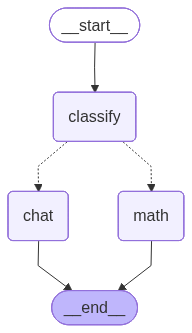

{'question': 'What is 3 * 4?', 'branch': 'math', 'result': '[math branch] You asked: What is 3 * 4?'}
{'question': 'Hello!', 'branch': 'chat', 'result': '[chat branch] You asked: Hello!'}


In [3]:
class RouteState(TypedDict):
    question: str
    branch: str
    result: str


def classify(state: RouteState) -> dict:
    q = state["question"].lower()
    if any(x in q for x in ("*", "times", "multiply", "+", "plus", "calculate")):
        return {"branch": "math"}
    return {"branch": "chat"}


def math_line(state: RouteState) -> dict:
    return {"result": f"[math branch] You asked: {state['question']}"}


def chat_line(state: RouteState) -> dict:
    return {"result": f"[chat branch] You asked: {state['question']}"}


def pick(state: RouteState) -> Literal["math", "chat"]:
    return state["branch"]  # must match keys in the mapping dict


rb = StateGraph(RouteState)
rb.add_node("classify", classify)
rb.add_node("math", math_line)
rb.add_node("chat", chat_line)
rb.add_edge(START, "classify")
rb.add_conditional_edges("classify", pick, {"math": "math", "chat": "chat"})
rb.add_edge("math", END)
rb.add_edge("chat", END)

router_app = rb.compile()
show_graph_safe(router_app, "2. Router — conditional edges")
print(router_app.invoke({"question": "What is 3 * 4?", "branch": "", "result": ""}))
print(router_app.invoke({"question": "Hello!", "branch": "", "result": ""}))

## 3. Subgraph as a node (shared state)

When the **parent and subgraph use the same state keys**, pass the **compiled** subgraph directly to `add_node` — no wrapper.

See [Add a subgraph as a node](https://docs.langchain.com/oss/python/langgraph/use-subgraphs#add-a-subgraph-as-a-node).

### 3. Parent graph with subgraph as node (shared state)

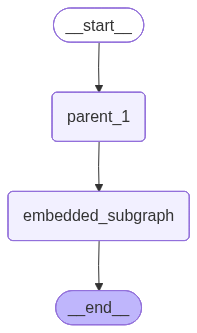

{'foo': 'subgraph says hi → parent: world'}


In [8]:
class SharedState(TypedDict):
    foo: str


def subgraph_step(state: SharedState) -> dict:
    return {"foo": "subgraph says hi → " + state["foo"]}


sub_b = StateGraph(SharedState)
sub_b.add_node("inner", subgraph_step)
sub_b.add_edge(START, "inner")
sub_b.add_edge("inner", END)
subgraph_app = sub_b.compile()

def parent_first(state: SharedState) -> dict:
    return {"foo": "parent: " + state["foo"]}


pb = StateGraph(SharedState)
pb.add_node("parent_1", parent_first)
pb.add_node("embedded_subgraph", subgraph_app)
pb.add_edge(START, "parent_1")
pb.add_edge("parent_1", "embedded_subgraph")
pb.add_edge("embedded_subgraph", END)

parent_shared = pb.compile()
show_graph_safe(parent_shared, "3. Parent graph with subgraph as node (shared state)")
print(parent_shared.invoke({"foo": "world"}))

## 4. Call a subgraph inside a node (different state)

When schemas **differ**, invoke the subgraph inside a node: map **parent state → subgraph input**, then map **subgraph output → parent state**.

See [Call a subgraph inside a node](https://docs.langchain.com/oss/python/langgraph/use-subgraphs#call-a-subgraph-inside-a-node).

### 4. Parent graph — subgraph invoked inside a node

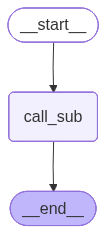

{'foo': 'start-value [processed in subgraph]'}


In [5]:
class SubState(TypedDict):
    bar: str


def sub_inner(state: SubState) -> dict:
    return {"bar": state["bar"] + " [processed in subgraph]"}


sub_only = StateGraph(SubState)
sub_only.add_node("only", sub_inner)
sub_only.add_edge(START, "only")
sub_only.add_edge("only", END)
sub_compiled = sub_only.compile()


class ParentOnlyState(TypedDict):
    foo: str


def bridge(state: ParentOnlyState) -> dict:
    out = sub_compiled.invoke({"bar": state["foo"]})
    return {"foo": out["bar"]}


wb = StateGraph(ParentOnlyState)
wb.add_node("call_sub", bridge)
wb.add_edge(START, "call_sub")
wb.add_edge("call_sub", END)

wrapped_app = wb.compile()
show_graph_safe(wrapped_app, "4. Parent graph — subgraph invoked inside a node")
print(wrapped_app.invoke({"foo": "start-value"}))

## 5. Bonus: conditional edge + LLM node

Same routing idea as section 2, but one branch calls **`llm.invoke`** so you see OpenAI in the graph. Requires a **valid API key**.

### 5. Conditional edges with an LLM node

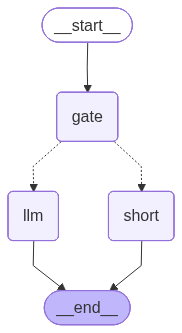

{'question': 'Hi', 'use_llm': False, 'answer': '(short path) Hi'}
---
{'question': 'In one sentence, what is LangGraph?', 'use_llm': False, 'answer': '(short path) In one sentence, what is LangGraph?'}


In [6]:
class LlmRouteState(TypedDict):
    question: str
    use_llm: bool
    answer: str


def gate(state: LlmRouteState) -> dict:
    return {"use_llm": len(state["question"]) > 40}


def llm_answer(state: LlmRouteState) -> dict:
    msg = llm.invoke([HumanMessage(content=state["question"])])
    return {"answer": msg.content}


def short_answer(state: LlmRouteState) -> dict:
    return {"answer": f"(short path) {state['question'][:80]}"}


def gate_pick(state: LlmRouteState) -> Literal["llm", "short"]:
    return "llm" if state["use_llm"] else "short"


lb = StateGraph(LlmRouteState)
lb.add_node("gate", gate)
lb.add_node("llm", llm_answer)
lb.add_node("short", short_answer)
lb.add_edge(START, "gate")
lb.add_conditional_edges("gate", gate_pick, {"llm": "llm", "short": "short"})
lb.add_edge("llm", END)
lb.add_edge("short", END)

llm_router = lb.compile()
show_graph_safe(llm_router, "5. Conditional edges with an LLM node")
print(llm_router.invoke({"question": "Hi", "use_llm": False, "answer": ""}))
print("---")
print(
    llm_router.invoke(
        {
            "question": "In one sentence, what is LangGraph?",
            "use_llm": False,
            "answer": "",
        }
    )
)

## 6. Minimal one-liner visualization (from docs style)

Equivalent to:

```python
from IPython.display import Image, display
png = app.get_graph().draw_mermaid_png()
display(Image(png))
```

Here `app` is any **compiled** graph from earlier cells, e.g. `router_app`.

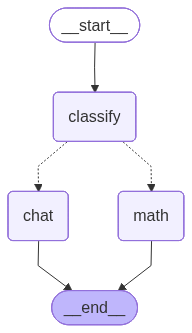

In [7]:
png = router_app.get_graph().draw_mermaid_png()
display(Image(png))

## Recap

| Topic | What you did |
|--------|----------------|
| **Conditional edge** | `add_conditional_edges("node", router_fn, {label: "next_node", ...})` |
| **Subgraph as node** | `add_node("name", compiled_subgraph)` when state channels align |
| **Subgraph inside node** | `subgraph.invoke(mapped_input)` then return mapped output |
| **Visualize** | `compiled.get_graph().draw_mermaid_png()` + `Image` / `display` |

Next: persistence (`checkpointer`), [subgraph streaming](https://docs.langchain.com/oss/python/langgraph/use-subgraphs#stream-subgraph-outputs), multi-agent patterns in the official **Subgraphs** guide.